# 01 — the data behind the benchmark

**Question.** What atmospheric and generation data does the analysis rest
on, and is the coverage complete and consistent enough to trust?

**Key results.**

- 33 local ERA5 caches cover five complete DJF winters plus validation windows; Z500 is also cached on the wider ±90°E blocking domain.
- A January sample has 0% NaN and no non-hourly gaps for `ws100`, `sp`, `ssrd` and `z500`.
- 1057 cached SMARD weekly files (66 weeks) give Dec–Feb generation and capacity for all four TSO zones.
- Latest installed capacity is ~86 GW solar, ~63 GW onshore wind and ~9 GW offshore (7.4 North Sea + 1.8 Baltic).

## Data

| source | variable | units | period | resolution | domain |
|---|---|---|---|---|---|
| ERA5 (ARCO) | 100 m wind (`ws100`), `sp`, `ssrd`, `z500` | m s⁻¹, Pa, W m⁻², m | five DJF winters 2020–21…2024–25 + validation windows | hourly, 0.25°; Z500 6-hourly | 30–75°N/–40–40°E; 30–85°N/–90–90°E for blocking |
| SMARD (BNetzA) | realised generation, installed capacity | MW | cached winter weeks | hourly | four TSO control zones + DE |

**Energy terms.** A *TSO zone* is the control area of one German
transmission operator (50Hertz, TenneT, Amprion, TransnetBW). *Installed
capacity* is the nameplate MW a fleet could produce; *capacity factor* (CF)
is generation ÷ capacity, the fraction of nameplate actually delivered.

In [1]:
# Purpose: project root, config, shared plotting style.
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from eurogrid import plotting

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))
plotting.apply_style()

In [2]:
# Purpose: inventory the local ERA5 caches -> one row per cached window.
import re

rows = []
for path in sorted(pathlib.Path(cfg["era5"]["cache_dir"]).glob("era5_*.zarr")):
    m = re.match(
        r"era5(_z500)?_(\d{8}T\d{2})_(\d{8}T\d{2})_lat([\d.]+)_([\d.]+)_lon(-?[\d.]+)_(-?[\d.]+)_z(\d+)h",
        path.name,
    )
    if not m:
        continue
    z500_only, s, e, la0, la1, lo0, lo1, stride = m.groups()
    rows.append(
        {"cache": path.name, "start": s, "end": e, "z500_only": bool(z500_only), "lon": f"{lo0}..{lo1}"}
    )
caches = pl.DataFrame(rows)
display(caches.group_by(["z500_only", "lon"]).agg(pl.len().alias("n_caches")).sort(["z500_only", "lon"]))
display(caches.group_by("start").agg(pl.len()).sort("start").head(40))

z500_only,lon,n_caches
bool,str,u32
false,"""-40..40""",41
true,"""-40..40""",5
true,"""-90..90""",5


start,len
str,u32
"""20200101T00""",1
"""20200201T00""",1
"""20201201T00""",6
"""20210101T00""",2
"""20210201T00""",2
…,…
"""20241101T00""",2
"""20241201T00""",4
"""20250101T00""",2


**Reading the inventory.** Two cache families exist: full hourly caches
(wind + surface pressure + solar irradiance, 30–75°N, ±40°E) covering the
five DJF winters and two validation windows, and Z500-only caches covering
the five winters on the wider blocking domain (30–85°N, ±90°E). The five
benchmark winters are 2020-12→2021-02 … 2024-12→2025-02.

In [3]:
# Purpose: open one full window and check completeness, units, ranges.
from datetime import datetime

from eurogrid.data.era5 import load_era5

ds = load_era5(
    datetime(2023, 1, 1),
    datetime(2023, 2, 1),
    **cfg["domain"],
    cache_dir=cfg["era5"]["cache_dir"],
    z500_stride_hours=cfg["era5"]["z500_stride_hours"],
)
qc = []
for var in ["ws100", "sp", "ssrd"]:
    da = ds[var]
    qc.append(
        {
            "variable": var,
            "units": da.attrs.get("units"),
            "NaN_fraction": float(da.isnull().mean()),
            "min": float(da.min()),
            "max": float(da.max()),
        }
    )
qc.append(
    {
        "variable": "z500",
        "units": ds["z500"].attrs.get("units"),
        "NaN_fraction": float(ds["z500"].isnull().mean()),
        "min": float(ds["z500"].min()),
        "max": float(ds["z500"].max()),
    }
)
display(pl.DataFrame(qc))
dt = np.diff(ds["time"].values).astype("timedelta64[h]").astype(int)
print("timesteps:", ds.sizes["time"], "| non-hourly gaps:", int((dt != 1).sum()))

variable,units,NaN_fraction,min,max
str,str,f64,f64,f64
"""ws100""","""m s-1""",0.0,0.000258,39.881458
"""sp""","""Pa""",0.0,63392.296875,104501.507812
"""ssrd""","""W m-2""",0.0,0.0,755.203186
"""z500""","""m""",0.0,4792.976074,5922.300781


timesteps: 744 | non-hourly gaps: 0


Every variable is complete (no NaNs, no gaps), in contract units. `ssrd`
reaches ~600–800 W m⁻² at winter noon — plausible for January mid-latitudes.
Z500 spans roughly 4800–5900 m, the expected range for the 500 hPa level.

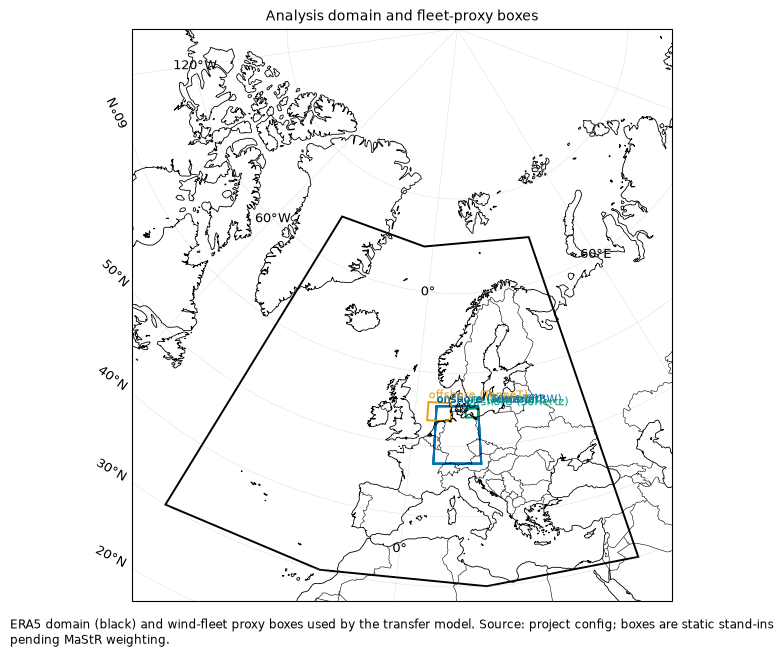

In [4]:
# Purpose: map of the analysis domain plus the fleet-proxy boxes used later.
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

from eurogrid.models.transfer import FLEET_BOXES

fig, ax = plotting.map_axes(extent=(-45, 45, 28, 90))
d = cfg["domain"]
ax.add_patch(
    mpatches.Rectangle(
        (d["lon_min"], d["lat_min"]),
        d["lon_max"] - d["lon_min"],
        d["lat_max"] - d["lat_min"],
        fill=False,
        edgecolor="k",
        lw=1.4,
        transform=ccrs.PlateCarree(),
        label="ERA5 domain",
    )
)
seen = set()
for (var, zone), (la0, la1, lo0, lo1) in FLEET_BOXES.items():
    col = plotting.PALETTE[0] if var == "wind_onshore" else plotting.PALETTE[1 + (zone == "50Hertz")]
    tag = f"{var.replace('wind_', '')} ({zone})"
    ax.add_patch(
        mpatches.Rectangle(
            (lo0, la0), lo1 - lo0, la1 - la0, fill=False, edgecolor=col, lw=1.4, transform=ccrs.PlateCarree()
        )
    )
    ax.text(lo0, la1 + 0.5, tag, transform=ccrs.PlateCarree(), fontsize=8, color=col)
ax.set_title("Analysis domain and fleet-proxy boxes")
plotting.caption(
    fig,
    "ERA5 domain (black) and wind-fleet proxy boxes used by the transfer model. "
    "Source: project config; boxes are static stand-ins pending MaStR weighting.",
)
plt.show()

**What this shows.** The black rectangle is the hourly-variable domain;
blocking uses a wider longitude strip (±90°E) so sectors are not truncated.
Onshore wind and solar share one Germany box; offshore is split between the
North Sea Bight (TenneT) and the Baltic (50Hertz), matching where the fleets
actually sit.

In [5]:
# Purpose: SMARD coverage and latest installed capacity per zone/technology.
from eurogrid.data.smard import SmardClient

files = sorted(pathlib.Path(cfg["smard"]["cache_dir"]).glob("*.parquet"))
weeks = sorted({f.name.rsplit("_", 1)[1].split(".")[0] for f in files})
print(
    "cached SMARD weekly files:",
    len(files),
    "| weeks:",
    len(weeks),
    "| first:",
    weeks[0],
    "| last:",
    weeks[-1],
)

cached SMARD weekly files: 1480 | weeks: 74 | first: 1606690800000 | last: 1740351600000


variable,GW
str,f64
"""solar""",86.4
"""wind_offshore""",9.2
"""wind_onshore""",63.2


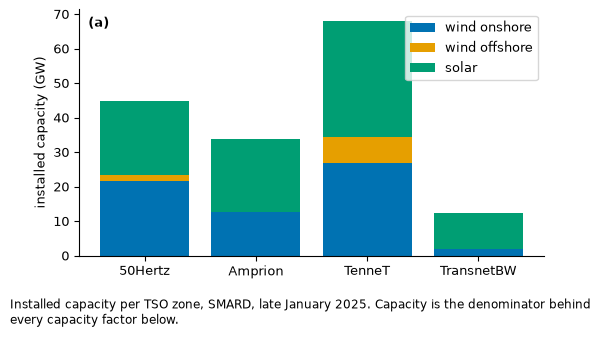

In [6]:
# Purpose: installed-capacity mix per zone at the latest cached timestamp.
client = SmardClient(cache_dir=cfg["smard"]["cache_dir"], pause_s=0)
cap = client.load_installed_capacity(datetime(2025, 1, 20), datetime(2025, 2, 1))
latest = cap.sort("time").group_by(["zone", "variable"]).last().sort(["zone", "variable"])

pivot = latest.pivot(on="variable", index="zone", values="value_mw").fill_null(0)
display(
    latest.group_by("variable").agg((pl.col("value_mw").sum() / 1000).round(1).alias("GW")).sort("variable")
)
fig, ax = plt.subplots(figsize=(6, 3.2))
bottom = np.zeros(pivot.height)
for var in ["wind_onshore", "wind_offshore", "solar"]:
    v = pivot[var].to_numpy() / 1000.0
    ax.bar(pivot["zone"].to_list(), v, bottom=bottom, label=var.replace("wind_", "wind "))
    bottom += v
ax.set_ylabel("installed capacity (GW)")
ax.legend()
plotting.label_panels(ax)
plotting.caption(
    fig,
    "Installed capacity per TSO zone, SMARD, late January 2025. "
    "Capacity is the denominator behind every capacity factor below.",
)
plt.show()

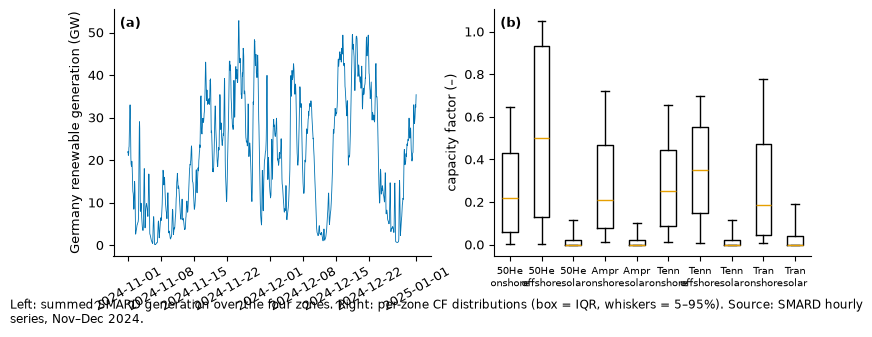

In [7]:
# Purpose: observed Germany-total generation and CF distributions (Nov-Dec 2024).
from eurogrid.data.smard import capacity_factor

gen = client.load_generation(datetime(2024, 11, 1), datetime(2025, 1, 1))
cap_w = client.load_installed_capacity(datetime(2024, 11, 1), datetime(2025, 1, 1))
cf = capacity_factor(gen, cap_w)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
tot = gen.group_by("time").agg(pl.col("value_mw").sum() / 1000).sort("time")
axes[0].plot(tot["time"].to_numpy(), tot["value_mw"].to_numpy(), lw=0.6)
axes[0].set_ylabel("Germany renewable generation (GW)")
axes[0].tick_params(axis="x", labelrotation=30)
data, labels = [], []
for zone in cf["zone"].unique().sort():
    for var in ["wind_onshore", "wind_offshore", "solar"]:
        sub = cf.filter(pl.col("zone") == zone, pl.col("variable") == var)["capacity_factor"].drop_nulls()
        if sub.len():
            data.append(sub.to_numpy())
            labels.append(f"{zone[:4]}\n{var.split('_')[-1]}")
axes[1].boxplot(data, tick_labels=labels, showfliers=False, whis=(5, 95))
axes[1].set_ylabel("capacity factor (–)")
axes[1].tick_params(axis="x", labelsize=7)
plotting.label_panels(axes)
plotting.caption(
    fig,
    "Left: summed SMARD generation over the four zones. Right: per-zone CF distributions "
    "(box = IQR, whiskers = 5–95%). Source: SMARD hourly series, Nov–Dec 2024.",
)
plt.show()

## Limitations and next step

- SMARD cache coverage is Dec–Feb weeks only; other seasons are not on disk.
- Fleet boxes are static proxies, not MaStR capacity-weighted footprints.
- SMARD `capacity_factor` can exceed 1 or sit at exactly 0 when capacity is
  updated mid-window; both are flagged, not corrected.
- **Next:** notebook 02 validates the ERA5 wind → CF transfer against this
  observed generation.